In [72]:
import math
import random
from copy import copy
from typing import Tuple, Union

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Pad, CenterCrop

TensorLike = Union[float, torch.Tensor]

In [10]:
def _as_tensor(x: TensorLike, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    return torch.as_tensor(x, device=device, dtype=dtype)


def to_radians(
    yaw: TensorLike,
    pitch: TensorLike,
    roll: TensorLike,
    degrees: bool = True,
    device: torch.device = torch.device("cpu"),
    dtype: torch.dtype = torch.float32,
):
    yaw_t = _as_tensor(yaw, device, dtype)
    pitch_t = _as_tensor(pitch, device, dtype)
    roll_t = _as_tensor(roll, device, dtype)

    if degrees:
        deg2rad = math.pi / 180.0
        yaw_t = yaw_t * deg2rad
        pitch_t = pitch_t * deg2rad
        roll_t = roll_t * deg2rad

    return yaw_t, pitch_t, roll_t


def make_2d_rot_matrix(
    yaw: TensorLike,
    pitch: TensorLike,
    roll: TensorLike,
    degrees: bool,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    """
    입력 yaw/pitch/roll:
      - 스칼라(float) 또는
      - (B,) 텐서

    반환: (B, 2, 2) 행렬 (스칼라이면 B=1로 취급 가능)
    """
    yaw_t, pitch_t, roll_t = to_radians(yaw, pitch, roll, degrees=degrees, device=device, dtype=dtype)

    # (B,)로 정규화 (스칼라면 0-dim 텐서일 수 있으니 view(-1)로 통일)
    yaw_t = yaw_t.view(-1)
    pitch_t = pitch_t.view(-1)
    roll_t = roll_t.view(-1)

    cy, cp, cr = torch.cos(yaw_t), torch.cos(pitch_t), torch.cos(roll_t)
    sy, sp, sr = torch.sin(yaw_t), torch.sin(pitch_t), torch.sin(roll_t)

    B = yaw_t.shape[0]
    zeros = torch.zeros(B, device=device, dtype=dtype)
    ones = torch.ones(B, device=device, dtype=dtype)

    # yaw: x축만 cos(yaw) 만큼 축소
    yaw_only = torch.stack(
        [
            torch.stack([cy, zeros], dim=-1),
            torch.stack([zeros, ones], dim=-1),
        ],
        dim=-2,
    )  # (B, 2, 2)

    # pitch: y축만 cos(pitch) 만큼 축소
    pitch_only = torch.stack(
        [
            torch.stack([ones, zeros], dim=-1),
            torch.stack([zeros, cp], dim=-1),
        ],
        dim=-2,
    )  # (B, 2, 2)

    # roll: 2D 회전
    roll_only = torch.stack(
        [
            torch.stack([cr, -sr], dim=-1),
            torch.stack([sr, cr], dim=-1),
        ],
        dim=-2,
    )  # (B, 2, 2)

    # [x_out; y_out] = Mroll * Mpitch * Myaw * [u; v]
    M = roll_only @ pitch_only @ yaw_only  # (B, 2, 2)
    return M


def partial_perspective(
    height: int,
    width: int,
    yaw: TensorLike,
    pitch: TensorLike,
    roll: TensorLike,
    degrees: bool,
    device: torch.device,
    dtype: torch.dtype,
    yaw_persp_strength: TensorLike = 0.3,    # (B,) 또는 스칼라
    pitch_persp_strength: TensorLike = 0.3,  # (B,) 또는 스칼라
    eps: float = 1e-6,
) -> torch.Tensor:
    """
    반환: grid (B, H, W, 2)
      - 각 샘플마다 다른 yaw/pitch/roll 및 원근 강도 지원
    """
    # (1) 회전 행렬과 역행렬 (B,2,2)
    M = make_2d_rot_matrix(
        yaw=yaw,
        pitch=pitch,
        roll=roll,
        degrees=degrees,
        device=device,
        dtype=dtype,
    )

    # B 결정: yaw/pitch/roll 중 make_2d_rot_matrix에서 view(-1)로 맞춘 B를 사용
    B = M.shape[0]
    M_inv = torch.inverse(M)  # (B,2,2)

    # (2) 출력 좌표 [-1,1]^2 (H,W) -> (B,H,W)로 브로드캐스트
    ys, xs = torch.meshgrid(
        torch.linspace(-1.0, 1.0, height, device=device, dtype=dtype),
        torch.linspace(-1.0, 1.0, width, device=device, dtype=dtype),
        indexing="ij",
    )
    x_f = xs.unsqueeze(0).expand(B, -1, -1)  # (B,H,W)
    y_f = ys.unsqueeze(0).expand(B, -1, -1)  # (B,H,W)

    # 각도 (B,)
    yaw_t, pitch_t, _ = to_radians(yaw, pitch, 0.0, degrees=degrees, device=device, dtype=dtype)
    yaw_t = yaw_t.view(-1)
    pitch_t = pitch_t.view(-1)

    # strength (B,)
    yaw_k = _as_tensor(yaw_persp_strength, device, dtype).view(-1)
    pitch_k = _as_tensor(pitch_persp_strength, device, dtype).view(-1)

    # 스칼라 strength면 B에 맞춰 expand
    if yaw_k.numel() == 1:
        yaw_k = yaw_k.expand(B)
    if pitch_k.numel() == 1:
        pitch_k = pitch_k.expand(B)

    # 기존 코드가 strength>0에서만 적용했는데, range에 음수가 들어오는 경우가 많아서
    # "강도는 크기, 방향은 각도 부호"로 해석하면 더 자연스럽습니다.
    yaw_k = yaw_k.abs()
    pitch_k = pitch_k.abs()

    # (3) pitch 원근 역변환: x_f -> x_prime (멀어지는 y쪽에서 x가 더 줄어든 느낌)
    x_prime = x_f
    y_prime = y_f

    pitch_active = (pitch_k > 0) & (pitch_t.abs() > eps)
    if pitch_active.any():
        sign_pitch = torch.where(pitch_t >= 0,
                                 torch.ones_like(pitch_t),
                                 -torch.ones_like(pitch_t))  # (B,)

        # 기존: 멀어지는 쪽만 0..1
        # t_pitch = sign_pitch[:,None,None] * y_prime
        # rel_pitch = clamp(t_pitch, 0..1)

        # 변경: -1..1 (한쪽 확대, 반대쪽 축소)
        t_pitch_signed = sign_pitch[:, None, None] * y_prime          # (B,H,W), 대략 [-1,1]
        t_pitch_signed = torch.clamp(t_pitch_signed, -1.0, 1.0)

        scale_p = 1.0 - pitch_k[:, None, None] * t_pitch_signed       # t=-1 => 1+k(확대), t=+1 => 1-k(축소)
        scale_p = torch.clamp(scale_p, min=0.05, max=20.0)            # 발산/특이점 방지(선호에 맞게 max 조절)

        scale_p = torch.where(pitch_active[:, None, None], scale_p, torch.ones_like(scale_p))
        x_prime = x_f / scale_p

    # (4) yaw 원근 역변환: y_f -> y_o (멀어지는 x쪽에서 y가 더 줄어든 느낌)
    x_o = x_prime
    y_o = y_prime

    yaw_active = (yaw_k > 0) & (yaw_t.abs() > eps)
    if yaw_active.any():
        sign_yaw = torch.where(yaw_t >= 0,
                               torch.ones_like(yaw_t),
                               -torch.ones_like(yaw_t))  # (B,)

        # 변경: -1..1 (한쪽 확대, 반대쪽 축소)
        t_yaw_signed = sign_yaw[:, None, None] * x_o
        t_yaw_signed = torch.clamp(t_yaw_signed, -1.0, 1.0)

        scale_y = 1.0 - yaw_k[:, None, None] * t_yaw_signed
        scale_y = torch.clamp(scale_y, min=0.05, max=20.0)

        scale_y = torch.where(yaw_active[:, None, None], scale_y, torch.ones_like(scale_y))
        y_o = y_f / scale_y

    # (5) 직교 역변환: [u; v] = M_inv @ [x_o; y_o]
    coords_o = torch.stack([x_o, y_o], dim=-1)  # (B,H,W,2)
    coords_flat = coords_o.reshape(B, -1, 2).permute(0, 2, 1)  # (B,2,N)

    coords_in = torch.bmm(M_inv, coords_flat.type_as(M_inv))  # (B,2,N)

    u = coords_in[:, 0, :].view(B, height, width)
    v = coords_in[:, 1, :].view(B, height, width)

    grid = torch.stack([u, v], dim=-1)  # (B,H,W,2)
    return grid


def rotate_with_perspective(
    image: torch.Tensor,
    yaw: TensorLike,
    pitch: TensorLike,
    roll: TensorLike,
    degrees: bool = True,
    padding_mode: str = "zeros",
    yaw_persp_strength: TensorLike = 0.3,
    pitch_persp_strength: TensorLike = 0.3,
) -> torch.Tensor:
    is_batched = (image.dim() == 4)
    if image.dim() == 3:
        image_b = image.unsqueeze(0)  # (1,C,H,W)
    elif image.dim() == 4:
        image_b = image
    else:
        raise ValueError(f"Unsupported shape: {image.shape}")

    B, C, H, W = image_b.shape
    device = image_b.device

    # 1) grid/기하 계산은 무조건 float로 (정수 dtype 절대 금지)
    grid_dtype = torch.float32

    # 2) grid_sample 입력도 float 권장
    if image_b.dtype.is_floating_point:
        image_f = image_b
        need_cast_back = False
        orig_dtype = image_b.dtype
    else:
        # 보통 0..255 정수 이미지이므로 0..1로 스케일
        orig_dtype = image_b.dtype
        image_f = image_b.to(torch.float32)
        if image_f.max() > 1.0:
            image_f = image_f / 255.0
        need_cast_back = True

    grid = partial_perspective(
        height=H,
        width=W,
        yaw=yaw,
        pitch=pitch,
        roll=roll,
        degrees=degrees,
        device=device,
        dtype=grid_dtype,  # ★ 여기 중요: image dtype 말고 float 고정
        yaw_persp_strength=yaw_persp_strength,
        pitch_persp_strength=pitch_persp_strength,
    )  # (B,H,W,2) 또는 (1,H,W,2)

    if grid.shape[0] == 1 and B > 1:
        grid = grid.expand(B, -1, -1, -1)

    out = F.grid_sample(
        image_f,
        grid,
        mode="bilinear",
        padding_mode=padding_mode,
        align_corners=True,
    )

    if not is_batched:
        out = out.squeeze(0)

    # (선택) 입력이 정수였으면 다시 0..255로 되돌려 캐스팅
    if need_cast_back:
        out = (out * 255.0).round().clamp(0, 255).to(orig_dtype)

    return out

In [11]:
class RandomFace3DRotationOrthoDirPersp(nn.Module):
    """
    직교 회전 + 방향성 원근(배치 벡터화):
    - yaw → x 줄어듦 + 멀어지는 쪽에서 y까지 같이 줄어드는 느낌
    - pitch → y 줄어듦 + 멀어지는 쪽에서 x까지 같이 줄어드는 느낌
    """

    def __init__(
        self,
        yaw_range: Tuple[float, float] = (-20.0, 20.0),
        pitch_range: Tuple[float, float] = (-10.0, 10.0),
        roll_range: Tuple[float, float] = (-10.0, 10.0),
        p: float = 1.0,
        padding_mode: str = "zeros",
        degrees: bool = True,
        yaw_persp_strength: float = 0.5,
        pitch_persp_strength: float = 0.5,
    ):
        super().__init__()
        self._yaw_range = yaw_range
        self._pitch_range = pitch_range
        self._roll_range = roll_range
        self._p = p
        self._padding_mode = padding_mode
        self._degrees = degrees
        self._yaw_persp_strength = yaw_persp_strength
        self._pitch_persp_strength = pitch_persp_strength

    @staticmethod
    def _rand_uniform(shape, low: float, high: float, device, dtype):
        return torch.empty(shape, device=device, dtype=dtype).uniform_(low, high)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() not in (3, 4):
            raise ValueError(f"Input dim {x.dim()} is not supported.")

        # (C,H,W)도 (1,C,H,W)로 통일해서 배치로 처리
        single = (x.dim() == 3)
        if single:
            xb = x.unsqueeze(0)
        else:
            xb = x

        B, C, H, W = xb.shape
        device = xb.device

        # 샘플별로 적용 여부 마스크 (p<1일 때만 의미 있음)
        if self._p >= 1.0:
            apply_mask = torch.ones(B, device=device, dtype=torch.bool)
        elif self._p <= 0.0:
            apply_mask = torch.zeros(B, device=device, dtype=torch.bool)
        else:
            apply_mask = (torch.rand(B, device=device) < self._p)

        # 전부 skip이면 그대로 반환
        if not apply_mask.any():
            return x

        # 샘플별 파라미터 샘플링 (B,)
        yaw = random.sample(self._yaw_range, 1) * B
        pitch = random.sample(self._pitch_range, 1) * B
        roll = random.sample(self._roll_range, 1) * B

        yaw_persp_strength = self._yaw_persp_strength
        pitch_persp_strength = self._pitch_persp_strength

        # 변환은 전체 배치에 대해 한 번에 계산
        out_all = rotate_with_perspective(
            xb,
            yaw=yaw,
            pitch=pitch,
            roll=roll,
            degrees=self._degrees,
            padding_mode=self._padding_mode,
            yaw_persp_strength=yaw_persp_strength,
            pitch_persp_strength=pitch_persp_strength,
        )  # (B,C,H,W)

        # 마스크 적용: 변환 안 하는 샘플은 원본 유지
        apply_mask_bc = apply_mask.view(B, 1, 1, 1)
        out = torch.where(apply_mask_bc, out_all, xb)

        if single:
            return out.squeeze(0)
        return out

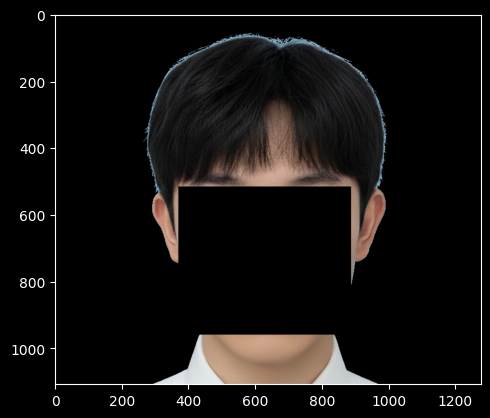

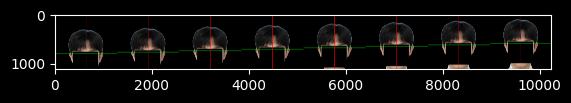

In [80]:
## Raw Image
from torchvision.utils import make_grid

img = cv.imread("../assets/example.png", cv.IMREAD_COLOR_RGB)
h,w,_ = img.shape

# daw ref lines
# cv.line(img, (w//2, 0), (w//2, h), (255, 0, 0), 5)
# cv.line(img, (0, h//2), (w, h//2), (0, 255, 0), 5)
plt.imshow(img)
plt.show()

# 움직이는 것처럼 보이기 위해 roll 추가

def shift_array(img, n: int, axis: int = 0):
    H, W, C = img.shape
    assert n >= 0 and C == 3
    array = copy(img)

    empty = np.zeros_like(array)
    if axis == 0:
        cv.line(array, (0, H//2), (W, H//2), (0, 255, 0), 5)
        min_height = min(n, H-1)
        max_height = max(0, H - n)
        empty[min_height:] = array[:max_height]


        cv.line(empty, (W//2, 0), (W//2, H), (255, 0, 0), 5)


    elif axis == 1:
        cv.line(array, (W//2, 0), (W//2, H), (255, 0, 0), 5)
        min_width = min(n, W-1)
        max_width = max(0, W - n)
        empty[:, min_width:] = array[:, :max_width]


        cv.line(empty, (0, H//2), (W, H//2), (0, 255, 0), 5)
    return empty



nrow = 8
roll_interval = 30
video = [torch.IntTensor(shift_array(img, i*roll_interval, axis=0)).permute(2, 0, 1) for i in range(nrow, 0, -1)]
video_grid = make_grid(video, nrow=nrow)
plt.figure()
plt.imshow(video_grid.permute(1, 2, 0).numpy())
plt.show()



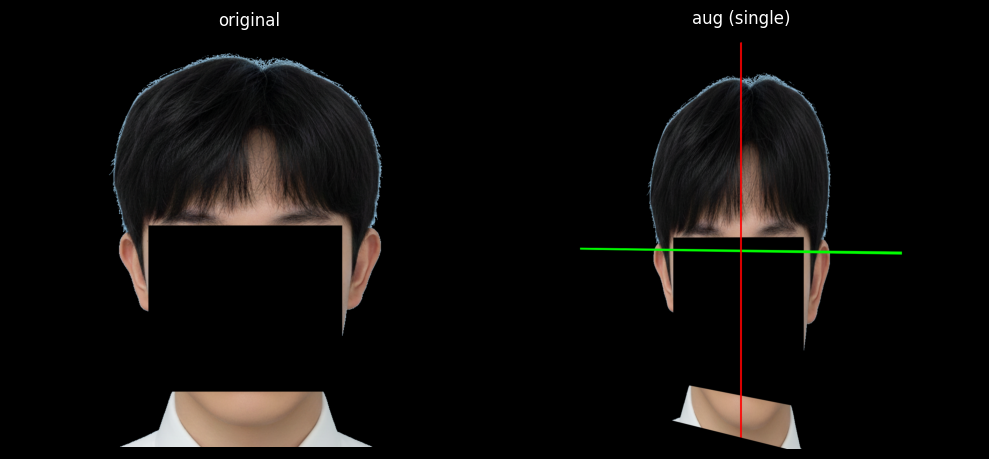

In [89]:
# -----------------------------
# 1) 파라미터(고정값 테스트)
# -----------------------------
yaw = -45
pitch = 0
yaw_pers = 0.3
pitch_pers = 0.3
pad_ratio = 0.025
# -----------------------------
# 2) transform 정의
# -----------------------------
_, H, W = video[0].shape
pad_size = int(round(max(H, W) * pad_ratio))

pad_aug = Pad(pad_size, fill=0, padding_mode="constant")
rot_aug = RandomFace3DRotationOrthoDirPersp(
    yaw_range=(yaw, yaw),
    pitch_range=(pitch, pitch),
    roll_range=(0.0, 0.0),
    p=1.0,
    padding_mode="zeros",      # zeros | border
    degrees=True,
    yaw_persp_strength=yaw_pers,
    pitch_persp_strength=pitch_pers,
)
crop_aug = CenterCrop((H, W))
# aug = Compose([pad_aug, rot_aug, crop_aug])
aug = Compose([pad_aug, rot_aug])

# -----------------------------
# 3) 단일 이미지 테스트 (C,H,W)
# -----------------------------
# img: PIL.Image 라고 가정

x = video[-1]                 # (C,H,W)
x_aug = aug(x)                     # (C,H,W)

fig = plt.figure(figsize=(10, 5))
ax1, ax2 = fig.subplots(1, 2)

ax1.set_title("original")
ax1.imshow(img)
ax1.axis("off")

ax2.set_title("aug (single)")
ax2.imshow(x_aug.to(torch.uint8).permute(1, 2, 0).cpu().numpy())
ax2.axis("off")

plt.tight_layout()
plt.show()

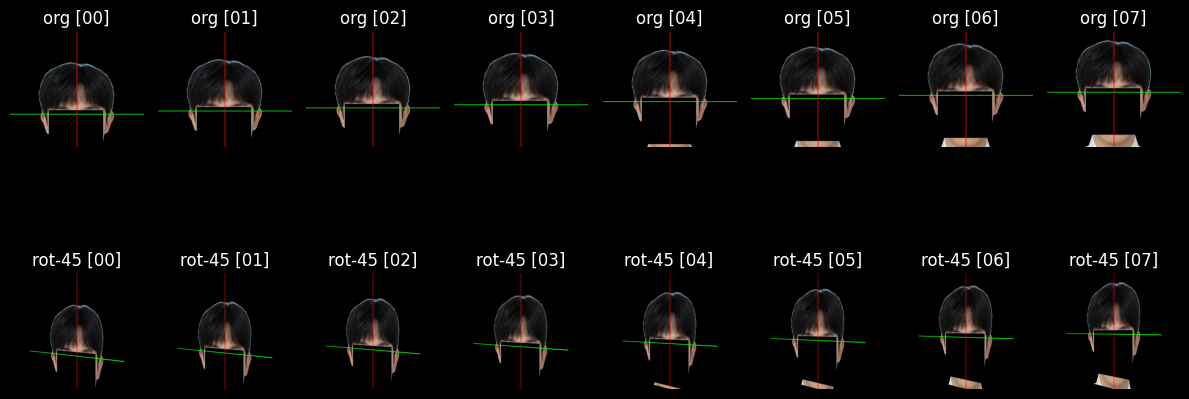

In [90]:
# -----------------------------
# 4) 배치 테스트 (B,C,H,W)
#    - 같은 이미지를 여러 장 복제해서, 배치 벡터화가 잘 되는지 확인
# -----------------------------
video_tensor = torch.stack(video, dim=0)
B = len(video_tensor)
xb = video_tensor
xb_aug = rot_aug(xb)                          # (B,C,H,W)

fig = plt.figure(figsize=(12, 6))
axes = fig.subplots(2, B)

for i in range(B):
    axes[0, i].set_title(f"org [{i:02d}]")
    axes[0, i].imshow(xb[i].permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis("off")

    axes[1, i].set_title(f"rot{yaw} [{i:02d}]")
    axes[1, i].imshow(xb_aug[i].permute(1, 2, 0).cpu().numpy())
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()
